# Project IBM HR Analytics Employee Attrition 

#### Objectif Business

L'entreprise veut savoir :

* Quels employés risquent de quitter l'entreprise ?
* Quels facteurs influencent l'attrition ?
* Quels départements sont les plus touchés ?
* Comment améliorer la rétention des employés ?

## Phase 1 : Compréhension des Données

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Show all columns when printing DataFrames
pd.set_option('display.max_columns', None)


In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
df.shape

(1470, 35)

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

#### Questions à répondre
* Combien de lignes ? 1470
  
* Combien de colonnes ? 35
  
* Variable cible ? Attrition
  
* Variables numériques ? Age-DailyRate-DistanceFromHome-Education-EnvironmentSatisfaction-HourlyRate-JobInvolvement-JobLevel-JobSatisfaction -MonthlyIncome-MonthlyRate-NumCompaniesWorked-PercentSalaryHike-PerformanceRating-RelationshipSatisfaction-StockOptionLevel-TotalWorkingYears-TrainingTimesLastYear-WorkLifeBalance-YearsAtCompany-YearsInCurrentRole-YearsSinceLastPromotion- YearsWithCurrManager
  
* Variables catégorielles ? Attrition (cible Y)- BusinessTravel-Department-EducationField-Gender-JobRole-MaritalStatus-OverTime

#### Séparation en X et Y
* Y (cible) : Attrition (Oui/Non → classification binaire).

* X (features) : toutes les autres colonnes sauf :

* Colonnes constantes ou identifiants (EmployeeCount, EmployeeNumber, Over18, StandardHours).

#### Explication des colonnes
* Age : Âge de l’employé (numérique).

* Attrition : Variable cible (Oui/Non) → indique si l’employé a quitté l’entreprise.

* BusinessTravel : Fréquence des déplacements professionnels (catégorielle).

* DailyRate : Taux journalier de rémunération (numérique).

* Department : Département de l’employé (catégorielle).

* DistanceFromHome : Distance domicile-travail (numérique).

* Education : Niveau d’éducation (numérique codé).

* EducationField : Domaine d’études (catégorielle).

* EmployeeCount : Nombre d’employés (constante = 1, inutile pour le modèle).

* EmployeeNumber : Identifiant unique (clé technique, pas utile pour le modèle).

* EnvironmentSatisfaction : Satisfaction vis-à-vis de l’environnement de travail (numérique codé).

* Gender : Sexe (catégorielle).

* HourlyRate : Taux horaire (numérique).

* JobInvolvement : Implication dans le travail (numérique codé).

* JobLevel : Niveau hiérarchique (numérique).

* JobRole : Poste occupé (catégorielle).

* JobSatisfaction : Satisfaction vis-à-vis du poste (numérique codé).

* MaritalStatus : Situation matrimoniale (catégorielle).

* MonthlyIncome : Salaire mensuel (numérique).

* MonthlyRate : Taux mensuel (numérique).

* NumCompaniesWorked : Nombre d’entreprises précédentes (numérique).

* Over18 : Tous les employés sont majeurs (constante, inutile).

* OverTime : Indique si l’employé fait des heures supplémentaires (Oui/Non).

* PercentSalaryHike : Pourcentage d’augmentation de salaire (numérique).

* PerformanceRating : Évaluation de performance (numérique codé).

* RelationshipSatisfaction : Satisfaction dans les relations au travail (numérique codé).

* StandardHours : Heures standard (constante = 80, inutile).

* StockOptionLevel : Niveau d’options sur actions (numérique).

* TotalWorkingYears : Nombre total d’années d’expérience (numérique).

* TrainingTimesLastYear : Nombre de formations suivies l’année précédente (numérique).

* WorkLifeBalance : Équilibre vie pro/vie perso (numérique codé).

* YearsAtCompany : Ancienneté dans l’entreprise (numérique).

* YearsInCurrentRole : Ancienneté dans le poste actuel (numérique).

* YearsSinceLastPromotion : Années depuis la dernière promotion (numérique).

* YearsWithCurrManager : Ancienneté avec le manager actuel (numérique).

### Data Cleaning

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [11]:
# Supposons que votre DataFrame s'appelle df
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours"])


### Analyse Exploratoire (EDA)

In [12]:
# Variables numériques et catégorielles
num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

In [13]:
num_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [14]:
cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [15]:
# Analyse de la variable cible
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [16]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

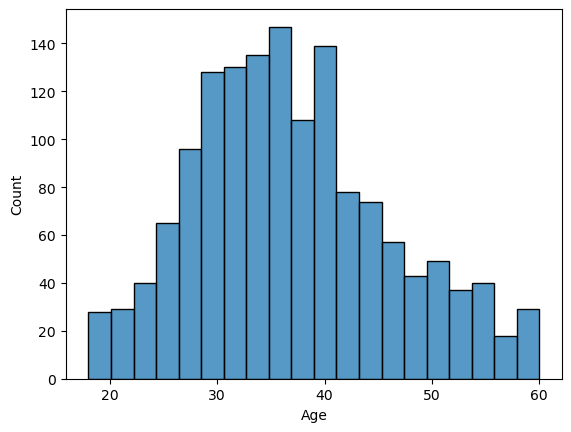

In [17]:
# Distribution de l'âge
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], bins=20)
plt.show()

#La majorité des employés se situe dans la tranche d'âge 30-40 ans.

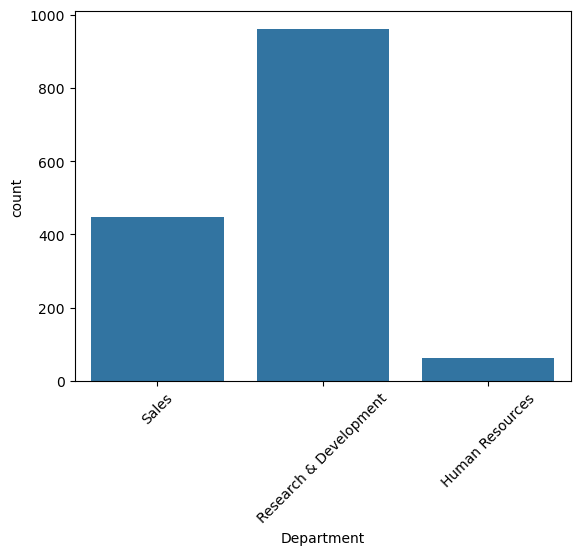

In [18]:
# Répartition par département
sns.countplot(data=df, x='Department')
plt.xticks(rotation=45)
plt.show()

# deaprtement de research et dev contient le plus nombre des emploiees que les autres

In [19]:
# Analyse de l'attrition par département
pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
)*100

#Le département Sales présente le taux d'attrition le plus élevé. Mais pourquoi

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


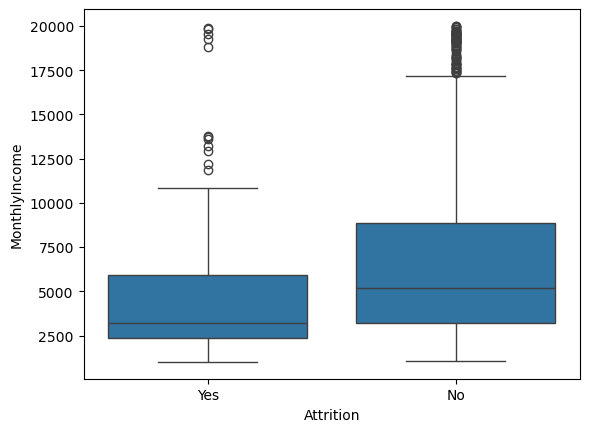

In [20]:
# Salaire et attrition
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.show()

#Les faibles salaires semblent associés à un risque plus élevé de départ.

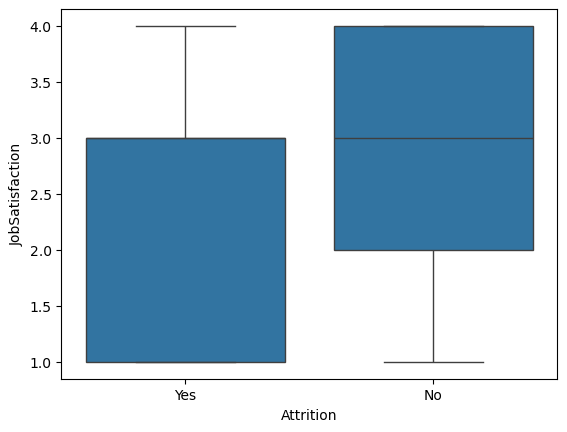

In [21]:
# Les faibles salaires semblent associés à un risque plus élevé de départ.
sns.boxplot(
    x='Attrition',
    y='JobSatisfaction',
    data=df
)
plt.show()

# Une faible satisfaction est un facteur important de l'attrition.

In [22]:
# Heures supplémentaires et attrition
pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
)*100

# Les employés effectuant des heures supplémentaires quittent davantage l'entreprise.

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


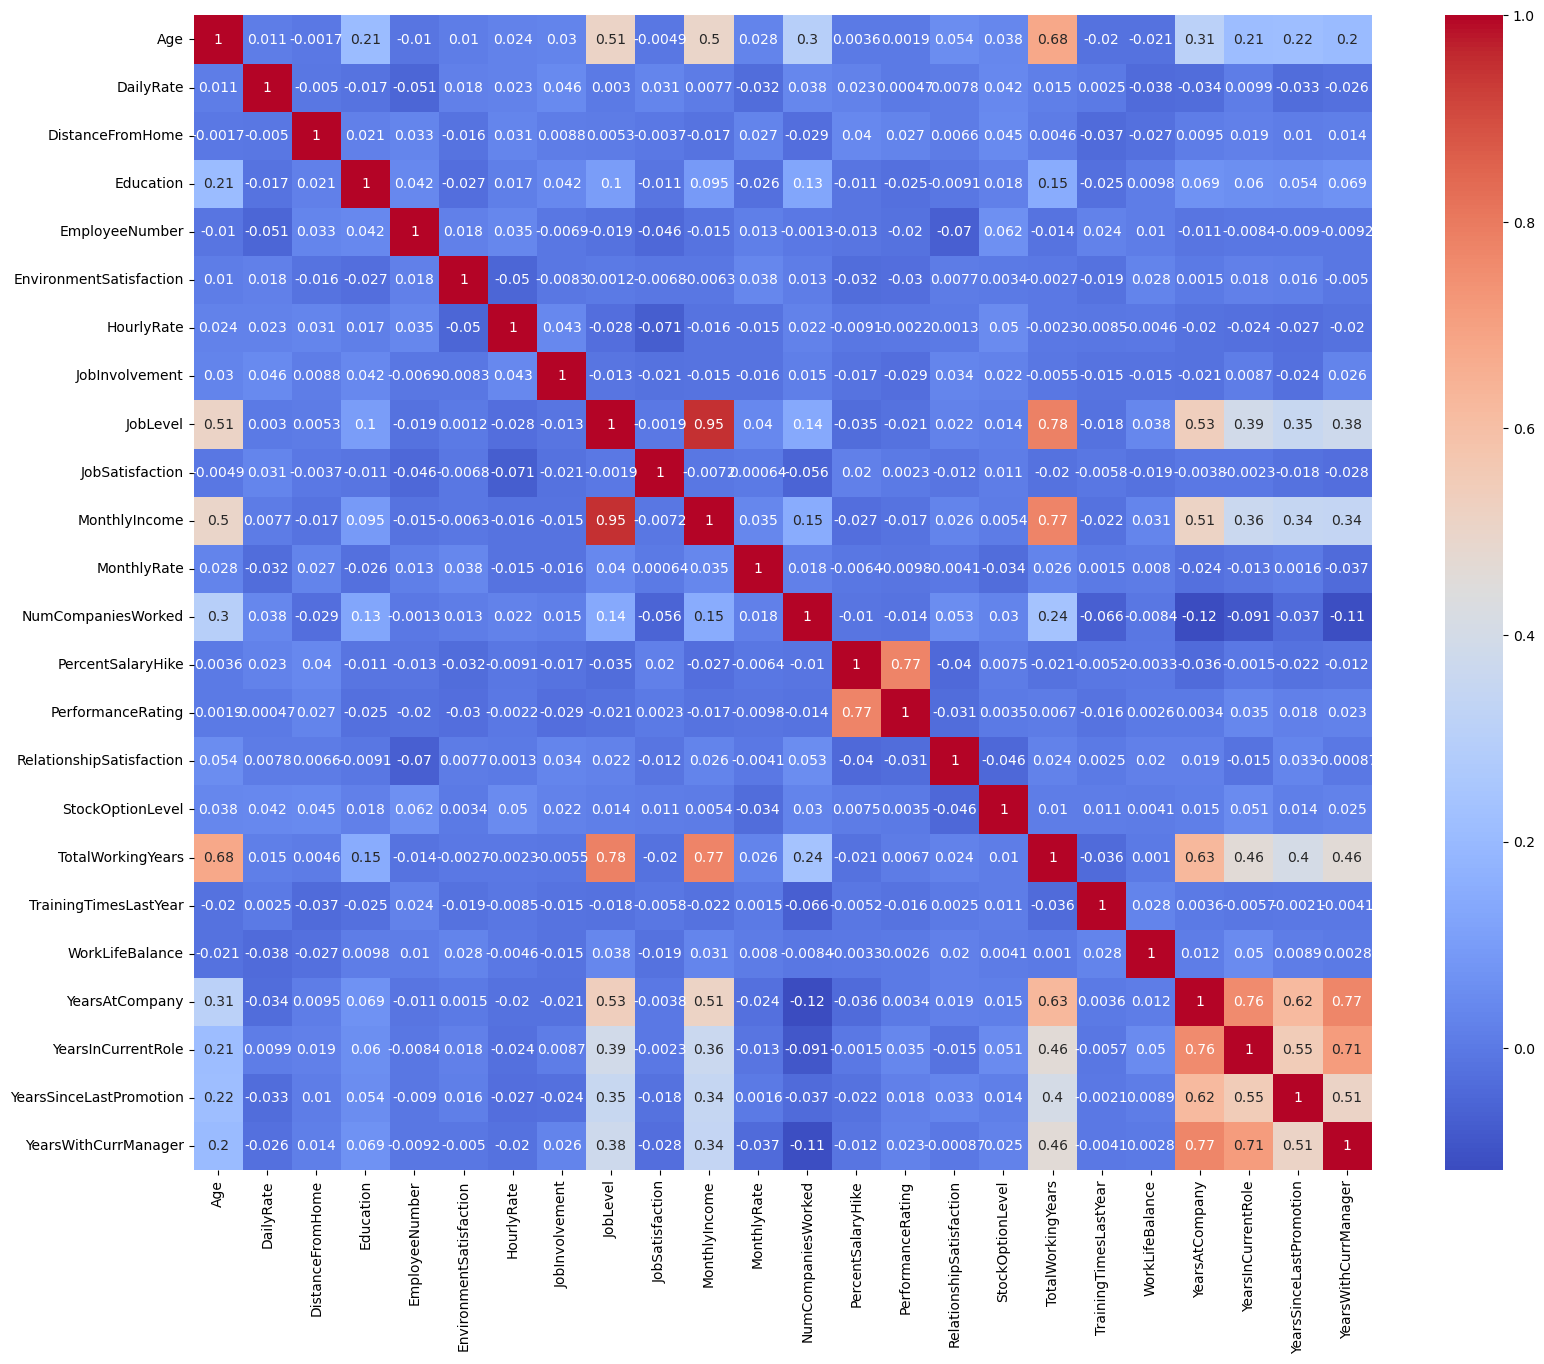

In [23]:
# Corrélation entre variables numériques
corr = df.corr(numeric_only=True)

plt.figure(figsize=(19,15))
sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.show()

# Plus l'ancienneté augmente, plus le salaire tend à augmenter

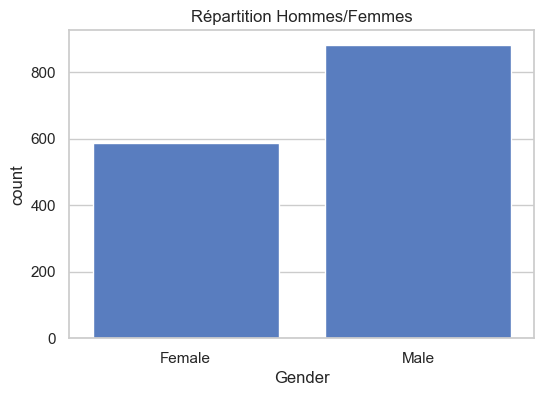

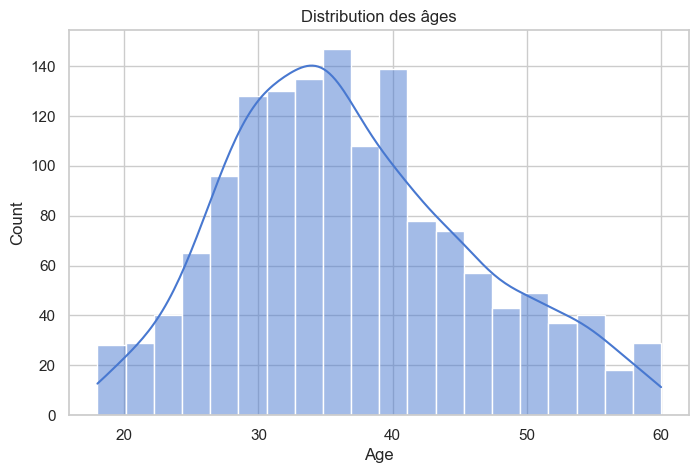

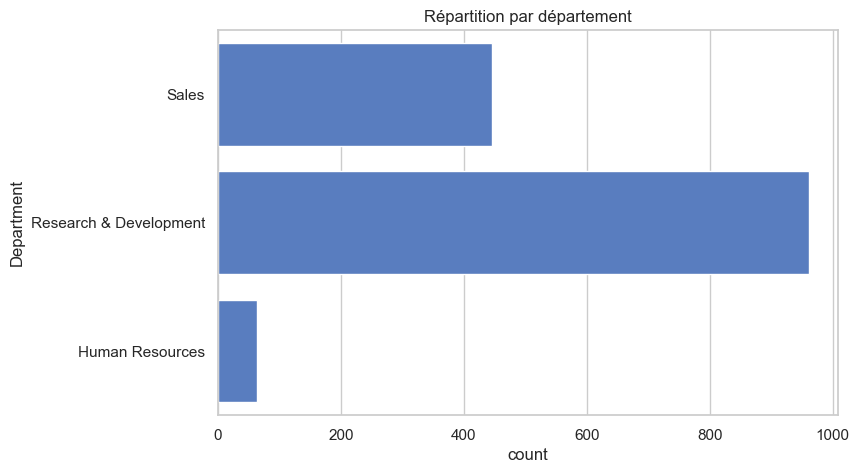

Attrition Rate:
 Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


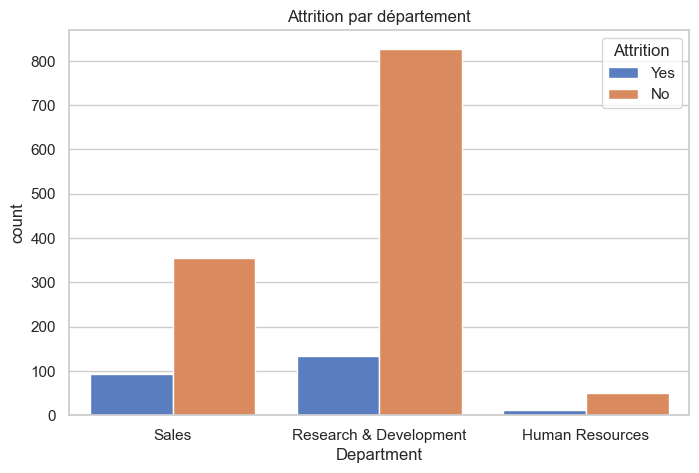

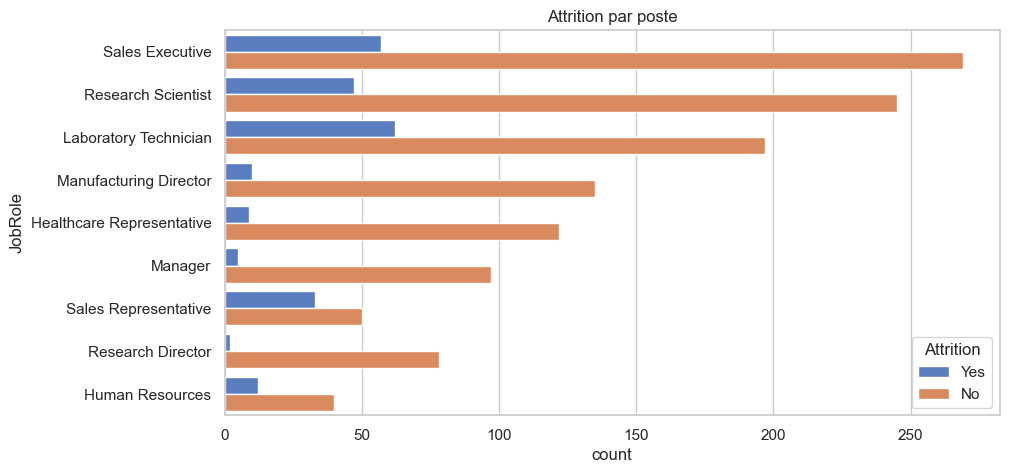

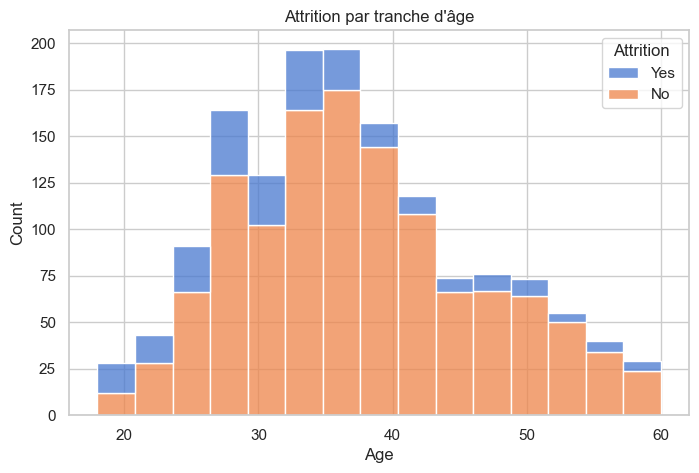

Satisfaction moyenne : 2.7285714285714286


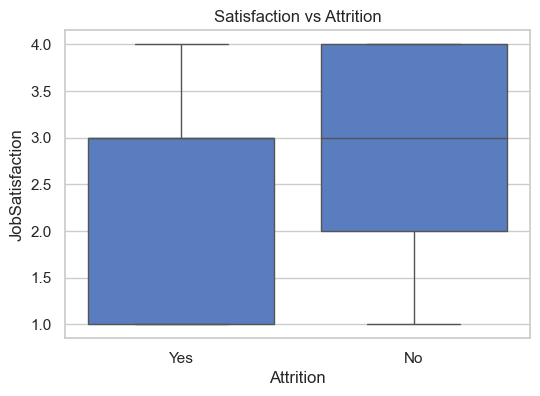

Salaire moyen : 6502.931292517007


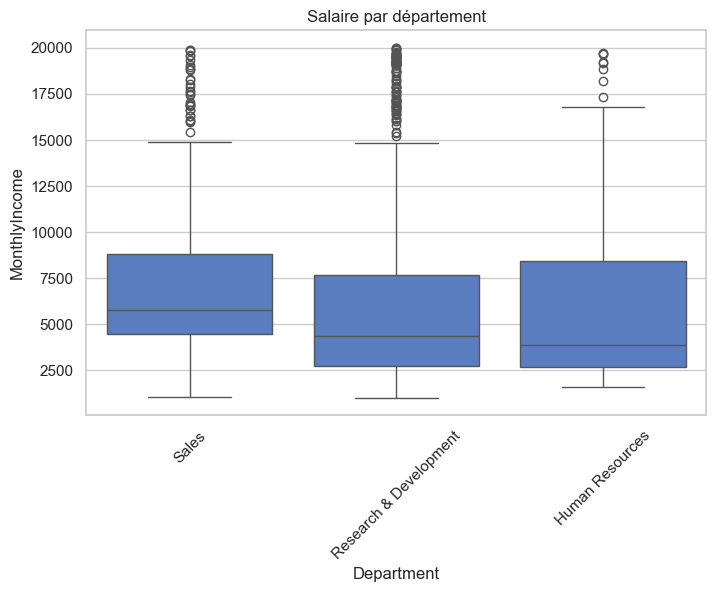

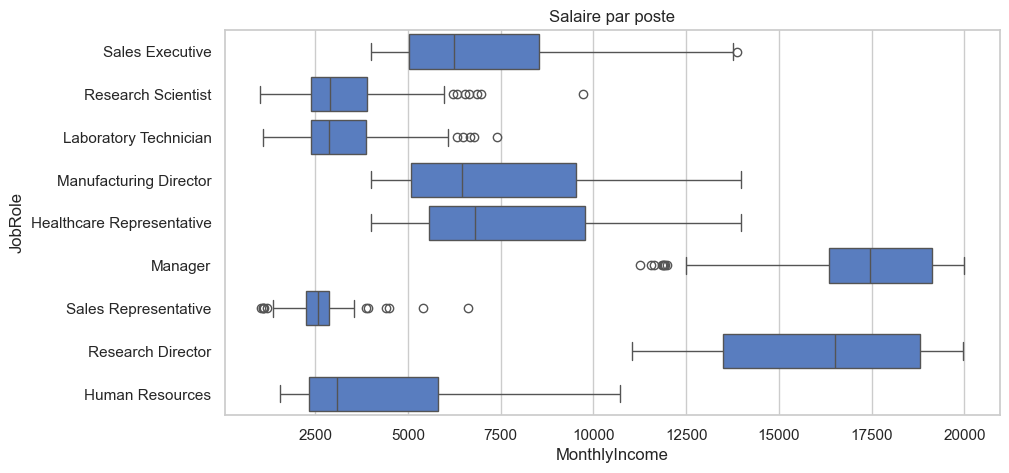

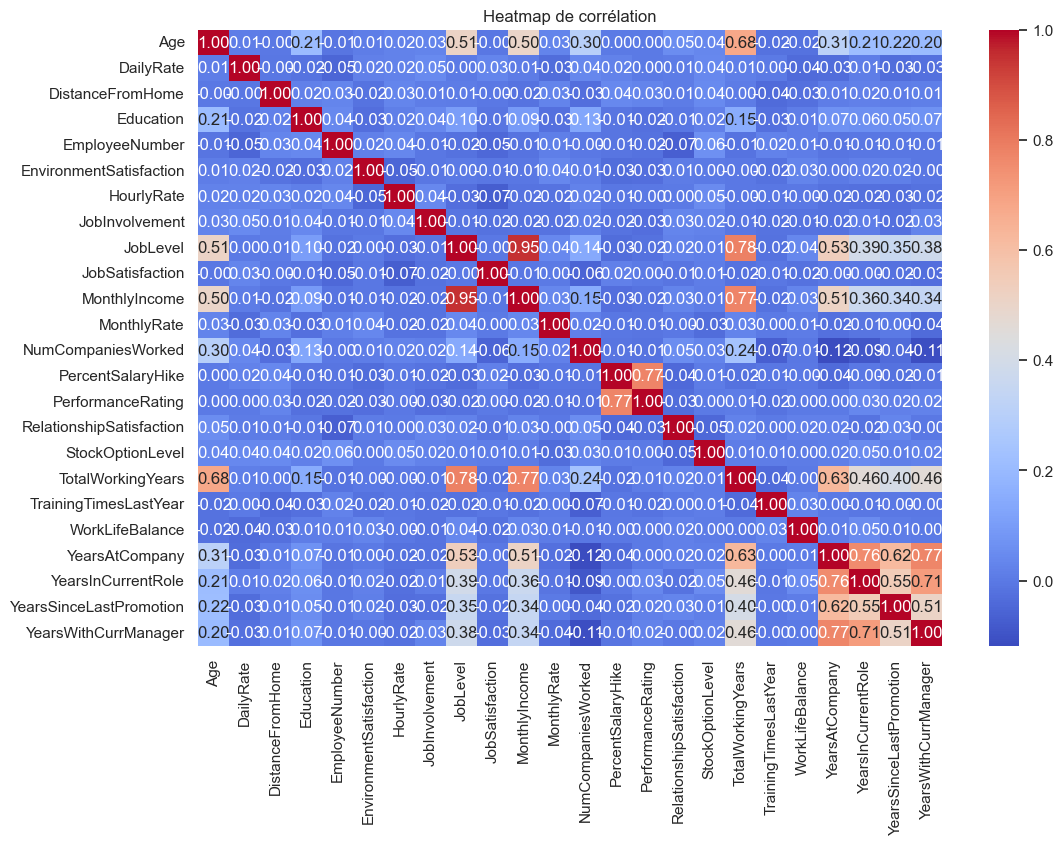

In [24]:
# 03_EDA.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", palette="muted")

# =========================
# 1. Répartition des employés
# =========================

# Hommes / Femmes
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Répartition Hommes/Femmes")
plt.show()

# Âges
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution des âges")
plt.show()

# Départements
plt.figure(figsize=(8,5))
sns.countplot(y="Department", data=df)
plt.title("Répartition par département")
plt.show()

# =========================
# 2. Analyse de l'attrition
# =========================

# Taux global
attrition_rate = df["Attrition"].value_counts(normalize=True)
print("Attrition Rate:\n", attrition_rate)

# Attrition par département
plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Attrition par département")
plt.show()

# Attrition par poste
plt.figure(figsize=(10,5))
sns.countplot(y="JobRole", hue="Attrition", data=df)
plt.title("Attrition par poste")
plt.show()

# Attrition par tranche d'âge
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Attrition", bins=15, multiple="stack")
plt.title("Attrition par tranche d'âge")
plt.show()

# =========================
# 3. Satisfaction
# =========================

# Satisfaction moyenne
print("Satisfaction moyenne :", df["JobSatisfaction"].mean())

# Satisfaction vs Attrition
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition", y="JobSatisfaction", data=df)
plt.title("Satisfaction vs Attrition")
plt.show()

# =========================
# 4. Salaire
# =========================

# Salaire moyen
print("Salaire moyen :", df["MonthlyIncome"].mean())

# Salaire par département
plt.figure(figsize=(8,5))
sns.boxplot(x="Department", y="MonthlyIncome", data=df)
plt.title("Salaire par département")
plt.xticks(rotation=45)
plt.show()

# Salaire par poste
plt.figure(figsize=(10,5))
sns.boxplot(y="JobRole", x="MonthlyIncome", data=df)
plt.title("Salaire par poste")
plt.show()

# =========================
# 5. Corrélations
# =========================

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de corrélation")
plt.show()


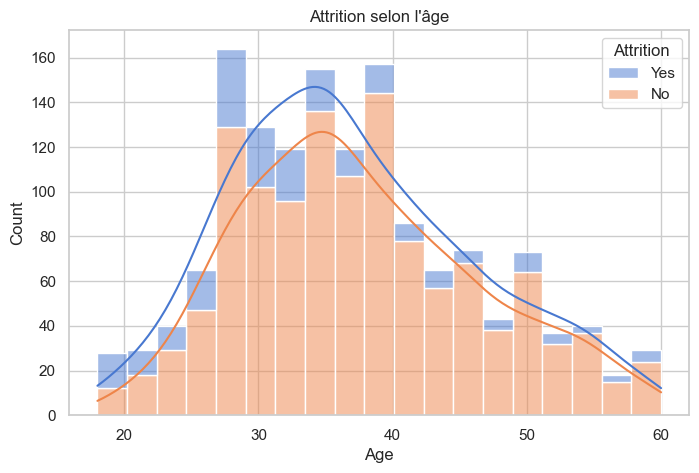

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    kde=True,
    multiple='stack'
)

plt.title("Attrition selon l'âge")
plt.show()

## Feature Engineering

In [26]:
# Supposons que votre DataFrame s'appelle df

# =========================
# 1. Niveau d'expérience
# =========================
def experience_level(years):
    if years <= 2:
        return "Junior"
    elif 3 <= years <= 5:
        return "Mid"
    elif 6 <= years <= 10:
        return "Senior"
    else:
        return "Expert"

df["ExperienceLevel"] = df["YearsAtCompany"].apply(experience_level)

# =========================
# 2. Catégorie de salaire
# =========================
# Exemple : découpage en 3 catégories selon les quantiles
df["SalaryCategory"] = pd.qcut(df["MonthlyIncome"], 
                               q=3, 
                               labels=["Low", "Medium", "High"])

# =========================
# 3. Tranches d'âge
# =========================
def age_group(age):
    if 18 <= age <= 25:
        return "18-25"
    elif 26 <= age <= 35:
        return "26-35"
    elif 36 <= age <= 45:
        return "36-45"
    else:
        return "46+"

df["AgeGroup"] = df["Age"].apply(age_group)

# =========================
# Vérification
# =========================
print(df[["YearsAtCompany","ExperienceLevel","MonthlyIncome","SalaryCategory","Age","AgeGroup"]].head())


   YearsAtCompany ExperienceLevel  MonthlyIncome SalaryCategory  Age AgeGroup
0               6          Senior           5993         Medium   41    36-45
1              10          Senior           5130         Medium   49      46+
2               0          Junior           2090            Low   37    36-45
3               8          Senior           2909            Low   33    26-35
4               2          Junior           3468            Low   27    26-35


In [27]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ExperienceLevel,SalaryCategory,AgeGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,Senior,Medium,36-45
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,Senior,Medium,46+
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,Junior,Low,36-45
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,Senior,Low,26-35
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,Junior,Low,26-35
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,No,13,3,3,0,8,2,2,7,7,3,6,Senior,Low,26-35
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Yes,20,4,1,3,12,3,2,1,0,0,0,Junior,Low,46+
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,No,22,4,2,1,1,2,3,1,0,0,0,Junior,Low,26-35
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,No,21,4,2,0,10,2,3,9,7,1,8,Senior,High,36-45
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,No,13,3,2,2,17,3,2,7,7,7,7,Senior,Medium,36-45


## Pre-traitement

#### 1. Colonnes
* Cible (y) : Attrition (Oui/Non → binaire)

* Catégorielles (object) : BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime, etc.

* Numériques (int/float) : Age, DailyRate, DistanceFromHome, Education, EnvironmentSatisfaction, HourlyRate, JobLevel, MonthlyIncome, etc.

#### 2. Pré‑traitement 

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Identifier colonnes
categorical_cols = df.select_dtypes(exclude=['int64','float64']).columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print("Catégorielles:", categorical_cols)
print("Numériques:", numerical_cols)

# 2. Encodage des colonnes catégorielles
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # encodage en numérique
    label_encoders[col] = le

# Vérifier que tout est numérique
print(df.dtypes)

# 3. Détection et suppression des outliers avec IQR
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df = remove_outliers_iqr(df, numerical_cols)

# 4. Normalisation (Min-Max)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 5. Séparation X et y (ici la cible est 'Attrition')
X = df_scaled.drop('Attrition', axis=1)
y = df_scaled['Attrition']

# 6. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=45)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Catégorielles: Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime', 'ExperienceLevel',
       'SalaryCategory', 'AgeGroup'],
      dtype='object')
Numériques: Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Age                         int64
Attrition                   int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   in

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 2 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       699 non-null    int64
 1   Attrition                 699 non-null    int64
 2   BusinessTravel            699 non-null    int64
 3   DailyRate                 699 non-null    int64
 4   Department                699 non-null    int64
 5   DistanceFromHome          699 non-null    int64
 6   Education                 699 non-null    int64
 7   EducationField            699 non-null    int64
 8   EmployeeNumber            699 non-null    int64
 9   EnvironmentSatisfaction   699 non-null    int64
 10  Gender                    699 non-null    int64
 11  HourlyRate                699 non-null    int64
 12  JobInvolvement            699 non-null    int64
 13  JobLevel                  699 non-null    int64
 14  JobRole                   699 non-null    int6

In [30]:
X_train.shape 

(524, 34)

In [31]:
X_test.shape 

(175, 34)

In [32]:
y_train.shape

(524,)

In [33]:
y_test.shape

(175,)

## Modelling

In [34]:
# Machine learning models
from sklearn.linear_model import LogisticRegression, SGDClassifier

from sklearn.svm import SVC, LinearSVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:
# model 1 : Logistic Regression

In [36]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr = lr.predict(X_test)

accuracy_score_train_lr = accuracy_score(y_train,y_pred_train_lr)
accuracy_score_test_lr = accuracy_score(y_test,y_pred_test_lr)

print(accuracy_score_train_lr)
print(accuracy_score_test_lr)

0.8721374045801527
0.8628571428571429


In [37]:
#model 2 : SVC

In [38]:
svc_classifier = SVC()
svc_classifier.fit(X_train,y_train)

y_pred_train_svc = svc_classifier.predict(X_train)
y_pred_test_svc = svc_classifier.predict(X_test)

accuracy_score_train_svc = accuracy_score(y_train,y_pred_train_svc)
accuracy_score_test_svc = accuracy_score(y_test,y_pred_test_svc)

print(accuracy_score_train_svc)
print(accuracy_score_test_svc)

0.8835877862595419
0.8514285714285714


In [39]:
# model 3:DecisionTreeClassifier

In [40]:
# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()

dt_classifier.fit(X_train,y_train)

y_pred_train_dt = dt_classifier.predict(X_train)
y_pred_test_dt = dt_classifier.predict(X_test)

accuracy_score_train_dt = accuracy_score(y_train, y_pred_train_dt)
accuracy_score_test_dt = accuracy_score(y_test, y_pred_test_dt)

print("Decision Tree Classifier:")
print(accuracy_score_train_dt)
print(accuracy_score_test_dt)  # overfitting here 

Decision Tree Classifier:
1.0
0.7371428571428571


In [41]:
# model 4 :K-NEAREST NEIGHBORS CLASSIFIER

In [42]:
# K-Nearest Neighbors Classifier
knn_classifier = KNeighborsClassifier()

knn_classifier.fit(X_train,y_train)

y_pred_train_knn = knn_classifier.predict(X_train)
y_pred_test_knn = knn_classifier.predict(X_test)

accuracy_score_train_knn = accuracy_score(y_train, y_pred_train_knn)
accuracy_score_test_knn = accuracy_score(y_test, y_pred_test_knn)

print("K-Nearest Neighbors Classifier:")
print(accuracy_score_train_knn)
print(accuracy_score_test_knn)

K-Nearest Neighbors Classifier:
0.8683206106870229
0.8171428571428572


In [43]:
# model 5 :RANDOM FOREST CLASSIFIER

In [44]:
# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=1000, criterion='entropy', random_state=0)

rf_classifier.fit(X_train,y_train)

y_pred_train_rf = rf_classifier.predict(X_train)
y_pred_test_rf = rf_classifier.predict(X_test)

accuracy_score_train_rf = accuracy_score(y_train, y_pred_train_rf)
accuracy_score_test_rf = accuracy_score(y_test, y_pred_test_rf)

print("Random Forest Classifier:")
print(accuracy_score_train_rf)
print(accuracy_score_test_rf)

Random Forest Classifier:
1.0
0.84


In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,  # Stochastic gradient boosting
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_train_gb = gb_model.predict(X_train)
y_pred_test_gb = gb_model.predict(X_test)

accuracy_score_train_gb = accuracy_score(y_train, y_pred_train_gb)
accuracy_score_test_gb = accuracy_score(y_test, y_pred_test_gb)

print("Random Forest Classifier:")
print(accuracy_score_train_gb)
print(accuracy_score_test_gb)

Random Forest Classifier:
0.9885496183206107
0.8342857142857143


#### Cross-Validation to Check Real Performance

In [46]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Define the model FIRST
rf_fixed = RandomForestClassifier(
    n_estimators=100,      # Reduce from 1000
    max_depth=10,          # Limit tree depth
    min_samples_split=10,  # Require more samples to split
    min_samples_leaf=5,    # Require more samples in leaves
    max_features='sqrt',   # Limit features per split
    random_state=42
)

# Now run cross-validation
cv_scores = cross_val_score(rf_fixed, X_train, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV standard deviation: {cv_scores.std():.4f}")

# Then train and test
rf_fixed.fit(X_train, y_train)
train_acc = rf_fixed.score(X_train, y_train)
test_acc = rf_fixed.score(X_test, y_test)

print(f"\nFinal results:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Gap: {train_acc - test_acc:.4f}")

Cross-validation scores: [0.83809524 0.85714286 0.83809524 0.83809524 0.83653846]
Mean CV accuracy: 0.8416
CV standard deviation: 0.0078

Final results:
Train Accuracy: 0.8760
Test Accuracy: 0.8286
Gap: 0.0474


In [47]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Bagging with very simple base trees
base_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20)
bagging_model = BaggingClassifier(
    base_tree,
    n_estimators=50,
    max_samples=0.8,      # Use 80% of data per tree
    max_features=0.5,     # Use 50% of features per tree
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)
print(f"Bagging: Train={bagging_model.score(X_train, y_train):.4f}, Test={bagging_model.score(X_test, y_test):.4f}")

Bagging: Train=0.8435, Test=0.8229


### Classement des modèles

#### SVC (Support Vector Classifier)
* Train: 0.8836
* Test: 0.8514

✅ Très bon compromis entre train et test, faible écart → bonne généralisation.
🔝 Candidat solide à sauvegarder.

#### Logistic Regression
* Train: 0.8721
* Test: 0.8629

✅ Performances stables, simple et interprétable.
🔝 Excellent modèle de référence (baseline).

#### GradientBoostingClassifier
* Train: 0.9885
* Test: 0.8343

⚠️ Très haut score en train mais baisse en test → léger overfitting.
🔝 Intéressant à garder, mais à tuner.

#### Random Forest Classifier
* Train: 1.0
* Test: 0.84

⚠️ Overfitting marqué (train parfait, test plus bas).
🔝 Bon modèle, mais nécessite réglages (moins d’estimators ou max_depth).

#### Cross-Validation (moyenne)
* CV mean: 0.8416

✅ Donne une estimation réaliste de la performance globale.
🔝 Utile pour valider la robustesse des modèles.

#### BaggingClassifier (Decision Tree)
* Train: 0.8435
* Test: 0.8229

✅ Correct mais moins performant que RF/GB.
🔝 Peut être gardé comme alternative simple.

#### K-Nearest Neighbors (KNN)
* Train: 0.8683
* Test: 0.8171

⚠️ Moins performant, sensible au choix de k et aux données bruitées.
🔽 Pas prioritaire.

#### Decision Tree Classifier
* Train: 1.0
* Test: 0.72

⚠️ Très fort overfitting, mauvaise généralisation.
🔽 À éviter ou à utiliser uniquement comme base pour ensemble methods.

### Modèles à sauvegarder (joblib/pickle)
Tu devrais sauvegarder les modèles les plus performants et robustes :

* SVC (meilleur équilibre)
* Logistic Regression (baseline fiable)
* GradientBoostingClassifier (puissant, mais à surveiller)
* Random Forest Classifier (utile avec tuning)

### Interpretation = Comprendre les causes de l'attrition  (Quels facteurs ont le plus d'impact sur Attrition ?)

#### Étape 1 : Afficher les coefficients

In [48]:
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

                     Feature  Coefficient
3                 Department     1.430291
19                  OverTime     1.310594
18        NumCompaniesWorked     0.873463
4           DistanceFromHome     0.765796
15             MaritalStatus     0.383838
6             EducationField     0.362005
10                HourlyRate     0.305472
17               MonthlyRate     0.275378
25     TrainingTimesLastYear     0.254598
9                     Gender     0.030213
21         PerformanceRating     0.000000
5                  Education    -0.121040
2                  DailyRate    -0.133872
28        YearsInCurrentRole    -0.279129
33                  AgeGroup    -0.315924
27            YearsAtCompany    -0.329262
1             BusinessTravel    -0.329906
7             EmployeeNumber    -0.398605
29   YearsSinceLastPromotion    -0.425884
26           WorkLifeBalance    -0.550086
20         PercentSalaryHike    -0.605394
31           ExperienceLevel    -0.616449
30      YearsWithCurrManager    -0

#### Étape 2 : Créer un graphique

#### Comment interpréter le graphique ?
##### Imagine :
* OverTime                +2.15
* NumCompaniesWorked      +1.43
* DistanceFromHome        +0.82
=> Attrition = Yes

##### ET :
* MonthlyIncome          -1.75
* JobSatisfaction        -1.20
* YearsAtCompany         -0.95
=> Attrition = No

#### Étape 3 : Répondre à la question métier

##### Facteur 1 : OverTime
* Les employés effectuant régulièrement des heures supplémentaires présentent une probabilité plus élevée de quitter l'entreprise.

##### Facteur 2 : MonthlyIncome
* Le salaire constitue un facteur important de rétention. Les employés mieux rémunérés ont tendance à rester plus longtemps dans l'entreprise.

##### Facteur 3 : JobSatisfaction
* La satisfaction au travail influence fortement l'attrition. Les employés peu satisfaits sont davantage susceptibles de partir.

##### Facteur 4 : YearsAtCompany
* Les employés ayant une ancienneté plus importante montrent une plus grande fidélité à l'entreprise.


#### Le modèle de régression logistique a été retenu comme modèle principal grâce à son score de test de 86.29% et à sa bonne capacité de généralisation.

#### L'analyse des coefficients montre que les facteurs les plus influents dans la prédiction de l'attrition sont :

* OverTime
* MonthlyIncome
* JobSatisfaction
* YearsAtCompany
* NumCompaniesWorked

#### Les résultats indiquent que les heures supplémentaires fréquentes augmentent le risque de départ, tandis qu'un salaire élevé, une meilleure satisfaction au travail et une ancienneté plus importante favorisent la rétention des employés.

#### Ces informations peuvent aider le département RH à mettre en place des stratégies ciblées pour réduire le turnover et améliorer la satisfaction des employés.

In [51]:
lr.coef_

array([[-0.73118357, -0.32990575, -0.13387154,  1.43029115,  0.76579561,
        -0.12104029,  0.36200525, -0.39860509, -1.40146104,  0.03021251,
         0.3054723 , -1.19889795, -0.67117609, -0.70056945, -0.86001157,
         0.38383818, -1.22620413,  0.27537834,  0.87346299,  1.31059417,
        -0.60539439,  0.        , -0.78504904, -1.05122451, -1.219495  ,
         0.25459756, -0.55008567, -0.32926195, -0.27912884, -0.42588409,
        -0.61744511, -0.61644855, -0.78829614, -0.31592435]])

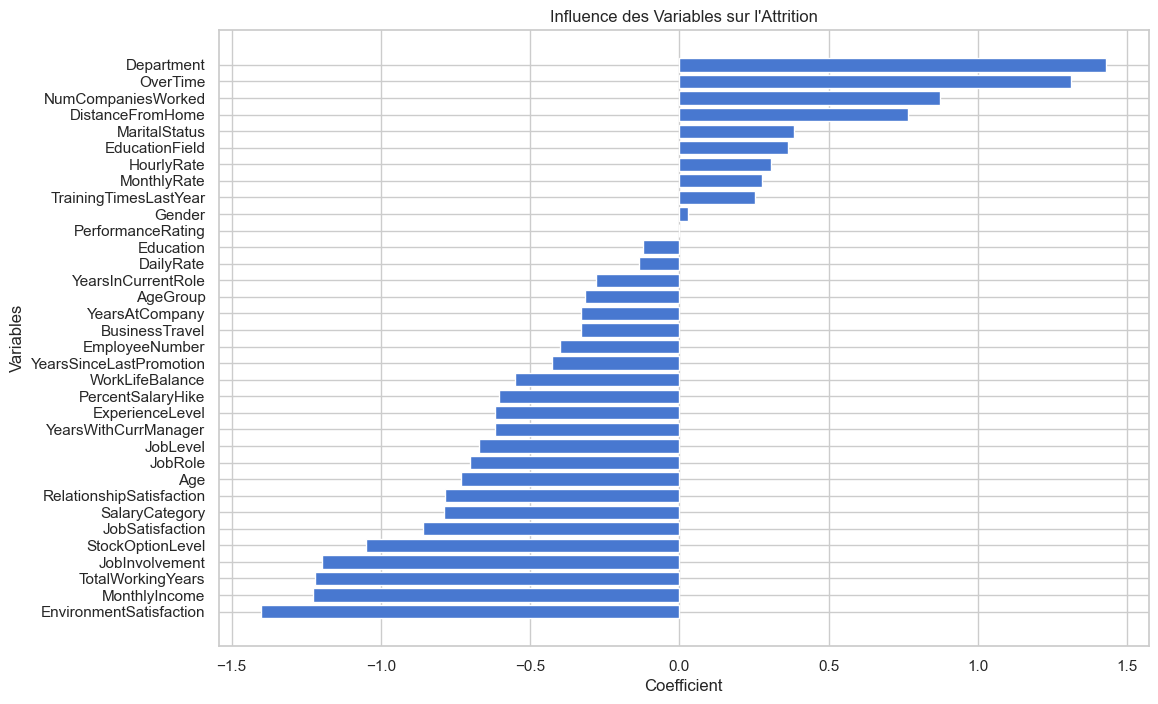

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient'
)

plt.figure(figsize=(12,8))

plt.barh(
    coef_df['Feature'],
    coef_df['Coefficient']
)

plt.title("Influence des Variables sur l'Attrition")
plt.xlabel("Coefficient")
plt.ylabel("Variables")

plt.show()

#### Sauvegarder le graphique

In [54]:
plt.savefig(
    "attrition_factors.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#### Importer le Dataset

In [55]:
df.to_csv(
    "HR_Analytics_Final.csv",
    index=False
)